# Zipf's Law by Language

In [1]:
# Load the preprocessed dataset
import os
import pandas as pd

catalog = pd.read_csv("../data/processed/catalog.csv", index_col="id")
print(f"Catalog contains {len(catalog)} books.")

languages = os.listdir("../data/processed/books/")
print(f"Found {len(languages)} languages: {languages}")

Catalog contains 76722 books.
Found 55 languages: ['af', 'ar', 'arp', 'bg', 'br', 'ca', 'ceb', 'cs', 'cy', 'da', 'de', 'el', 'en', 'enm', 'eo', 'es', 'et', 'fa', 'fi', 'fr', 'fur', 'fy', 'ga', 'gl', 'gla', 'he', 'hu', 'ia', 'ilo', 'is', 'it', 'iu', 'ja', 'la', 'mi', 'myn', 'nah', 'nap', 'nl', 'no', 'oc', 'oji', 'pl', 'pt', 'rmq', 'ro', 'ru', 'sa', 'sco', 'sl', 'sr', 'sv', 'te', 'tl', 'zh']


In [ ]:
from typing import List
from collections import Counter
import pandas as pd


def analyze_type_frequency(words: List[str]):
    # Count word frequencies
    word_counts = Counter(words)
    total_words = sum(word_counts.values())
    vocab_size = len(word_counts)

    # Create a DataFrame for analysis
    df = pd.DataFrame(word_counts.items(), columns=["word", "frequency"])
    df = df.sort_values(by="frequency", ascending=False).reset_index(drop=True)
    df["rank"] = df.index + 1
    df["relative_frequency"] = df["frequency"] / total_words
    df["cumulative_frequency"] = df["relative_frequency"].cumsum()
    return df, total_words, vocab_size

Processing book: 100 - The Complete Works of William Shakespeare by Shakespeare, William
  Total words in book: 973090
  Fitted parameters with OLS: alpha = 3.9502, beta = -1.5177
  Fitted parameters with NLS: 0 ± 0 * rank ^ (-0.73 ± 0.00)
Processing book: 1342 - Pride and Prejudice by Austen, Jane
  Total words in book: 128093
  Fitted parameters with OLS: alpha = 0.8752, beta = -1.3365
  Fitted parameters with NLS: 0 ± 0 * rank ^ (-0.73 ± 0.00)
Processing book: 145 - Middlemarch by Eliot, George
  Total words in book: 313728
  Fitted parameters with OLS: alpha = 0.7210, beta = -1.3039
  Fitted parameters with NLS: 0 ± 0 * rank ^ (-0.75 ± 0.00)
Processing book: 1513 - Romeo and Juliet by Shakespeare, William
  Total words in book: 29262
  Fitted parameters with OLS: alpha = 0.2150, beta = -1.0994
  Fitted parameters with NLS: 0 ± 0 * rank ^ (-0.69 ± 0.00)
Processing book: 16328 - Beowulf: An Anglo-Saxon Epic Poem by nan
  Total words in book: 37747
  Fitted parameters with OLS: alpha 

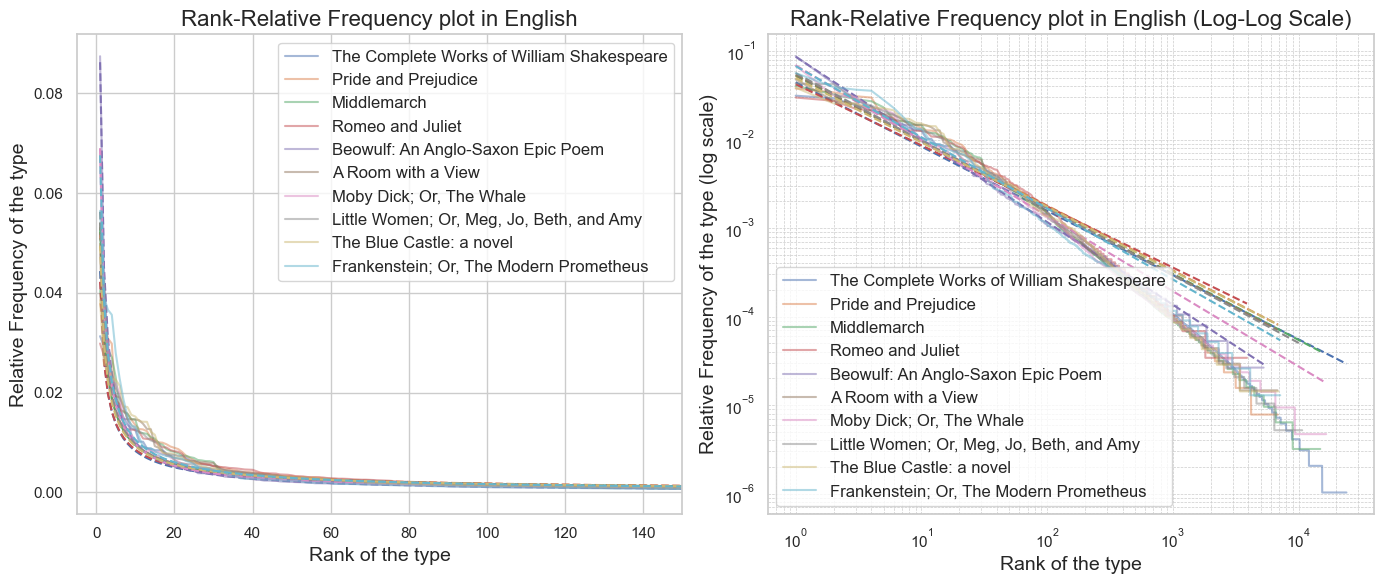

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid")


fig, ax = plt.subplots(1, 2, figsize=(14, 6))


def zipf(x, alpha, beta):
    return alpha * x ** (-beta)


books = os.listdir("../data/processed/books/en/")
for j, book in enumerate(books):
    book_id = int(book.removesuffix(".txt"))
    book_info = catalog.loc[book_id]

    print(f"Processing book: {book_id} - {book_info['title']} by {book_info['authors']}")
    with open(os.path.join("../data/processed/books/en/", book), "r", encoding="utf-8") as file:
        words = file.read().split()
    print(f"  Total words in book: {len(words)}")
    df, _, _ = analyze_type_frequency(words)
    model = LinearRegression()
    model.fit(np.log(df["rank"]).values.reshape(-1, 1), np.log(df["relative_frequency"]).values.reshape(-1, 1))
    beta_ols = model.coef_[0][0]
    alpha_ols = np.exp(model.intercept_[0])
    print(f"  Fitted parameters with OLS: alpha = {alpha_ols:.4f}, beta = {beta_ols:.4f}")

    (alpha, beta), pcov = curve_fit(zipf, df["rank"], df["relative_frequency"])
    print(f"  Fitted parameters with NLS: {alpha:.0f} ± {pcov[0][0]:.0f} * rank ^ (-{beta:.2f} ± {pcov[1][1]:.2f})")
    ax[0].plot(df["rank"], df["relative_frequency"], label=book_info["title"], alpha=0.5, color=f"C{j}")
    ax[0].plot(df["rank"], zipf(df["rank"], alpha, beta), linestyle="--", color=f"C{j}")
    ax[1].plot(df["rank"], df["relative_frequency"], label=book_info["title"], alpha=0.5, color=f"C{j}")
    ax[1].plot(df["rank"], zipf(df["rank"], alpha, beta), linestyle="--", color=f"C{j}")


ax[0].set_xlabel("Rank of the type")
ax[0].set_ylabel("Relative Frequency of the type")
ax[0].set_title(f"Rank-Relative Frequency plot in English")
ax[0].set_xlim(-5, 150)
ax[0].legend()
ax[1].grid(True, which="both", linestyle="--", linewidth=0.5)  # Add grid for better readability
ax[1].set_xlabel("Rank of the type")
ax[1].set_ylabel("Relative Frequency of the type (log scale)")
ax[1].set_title(f"Rank-Relative Frequency plot in English (Log-Log Scale)")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].legend()


for axis in ax:
    axis.title.set_fontsize(16)
    axis.xaxis.label.set_fontsize(14)
    axis.yaxis.label.set_fontsize(14)
    axis.legend(fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/zipf-by-language-english-raw.png", dpi=300)
plt.show()

In [ ]:
from typing import Tuple
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit

sns.set(style="whitegrid")


def zipf(x, alpha, beta):
    return alpha * x ** (-beta)


fitted_parameters: List[Tuple[str, int, int]] = []

for j, lang in enumerate(sorted(languages)):
    books = os.listdir(f"../data/processed/books/{lang}/")
    for book in books:
        book_id = int(book.removesuffix(".txt"))
        book_info = catalog.loc[book_id]

        print(f"Processing book: {book_id} - {book_info['title']} by {book_info['authors']}")
        with open(os.path.join("../data/processed/books", lang, book), "r", encoding="utf-8") as file:
            words = file.read().split()
        print(f"  Total words in book: {len(words)}")
        df, _, _ = analyze_type_frequency(words)

        model = LinearRegression()
        model.fit(np.log(df["rank"]).values.reshape(-1, 1), np.log(df["relative_frequency"]).values.reshape(-1, 1))
        beta_ols = model.coef_[0][0]
        alpha_ols = np.exp(model.intercept_[0])
        print(f"  Fitted parameters with OLS: alpha = {alpha_ols:.4f}, beta = {beta_ols:.4f}")

        (alpha, beta), pcov = curve_fit(zipf, df["rank"], df["relative_frequency"])
        print(f"  Fitted parameters with NLS: {alpha:.0f} ± {pcov[0][0]:.0f} * rank ^ (-{beta:.2f} ± {pcov[1][1]:.2f})")
        fitted_parameters.append((lang, alpha, beta))

parameters = pd.DataFrame(fitted_parameters, columns=["language", "alpha", "s"])

Processing book: 16543 - Trekkerswee Met tekeninge van J.H. Pierneef by Totius
  Total words in book: 11991
  Fitted parameters with OLS: alpha = 0.0714, beta = -0.8914
  Fitted parameters with NLS: 0 ± 0 * rank ^ (-0.81 ± 0.00)
Processing book: 18203 - Die prosa van die twede Afrikaanse beweging by Schoonees, P. C. (Pieter Cornelis)
  Total words in book: 102316
  Fitted parameters with OLS: alpha = 0.0740, beta = -0.9659
  Fitted parameters with NLS: 0 ± 0 * rank ^ (-0.88 ± 0.00)
Processing book: 19729 - Oom Gert Vertel en Ander Gedigte by Leipoldt, C. Louis (Christiaan Louis)
  Total words in book: 23745
  Fitted parameters with OLS: alpha = 0.1195, beta = -1.0002
  Fitted parameters with NLS: 0 ± 0 * rank ^ (-0.79 ± 0.00)
Processing book: 42302 - Digters uit Suid-Afrika  Bloemlesing uit die poësie van die Twede Afrikaanse-Taalbeweging by Celliers, Jan F. E. (Jan François Elias);Leipoldt, C. Louis (Christiaan Louis);Malherbe, Daniel François;Totius
  Total words in book: 24300
  Fit

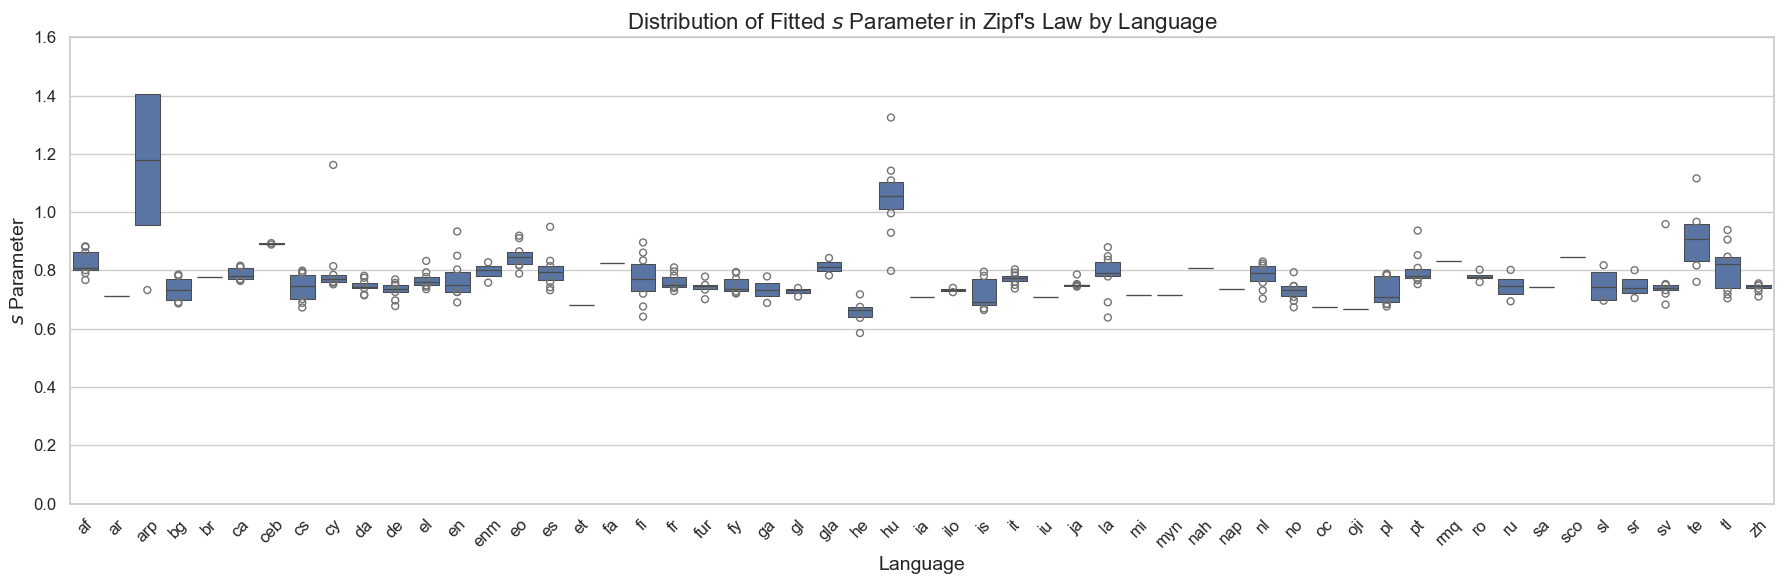

In [28]:
plt.figure(figsize=(18, 6))
sns.boxenplot(y="s", x="language", data=parameters)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.xlabel("Language", fontsize=14)
plt.ylabel("$s$ Parameter", fontsize=14)
plt.title("Distribution of Fitted $s$ Parameter in Zipf's Law by Language", fontsize=16)
plt.ylim(0, 1.6)
plt.tight_layout()
plt.savefig("../reports/figures/zipf-by-language-s.png", dpi=300)
plt.show()